In [2]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


In [9]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    pkg: str = "timm"
    k: int = 1
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 2.0
    alpha: float = 0.9

cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', model_name='vit_l_16', img_size=384, new_fs=100, pkg='timm', k=1, results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), cmap_name='plasma', line_width=2.0, alpha=0.9)

In [10]:
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(f"{len(layers)} layers")


24 layers


In [11]:
def static_dynii_save_name(layer_name, direction):
    return cfg.results_dir / f"dynII_{direction}_k{cfg.k}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"

curves = {"A2B": {}, "B2A": {}}
missing = {"A2B": [], "B2A": []}
for layer_name in layers:
    for direction in curves:
        save_name = static_dynii_save_name(layer_name, direction)
        if save_name.exists():
            curves[direction][layer_name] = np.load(save_name)["arr_0"]
        else:
            missing[direction].append(save_name)

if not any(curves[direction] for direction in curves):
    raise FileNotFoundError(f"No static dynII files found in {cfg.results_dir}")

for direction in curves:
    print(f"{direction}: loaded {len(curves[direction])} / {len(layers)} layers")
    if missing[direction]:
        print(f"{direction}: missing {len(missing[direction])} files")
        for save_name in missing[direction][:5]:
            print(save_name)


A2B: loaded 24 / 24 layers
B2A: loaded 24 / 24 layers


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_42795/2217740330.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


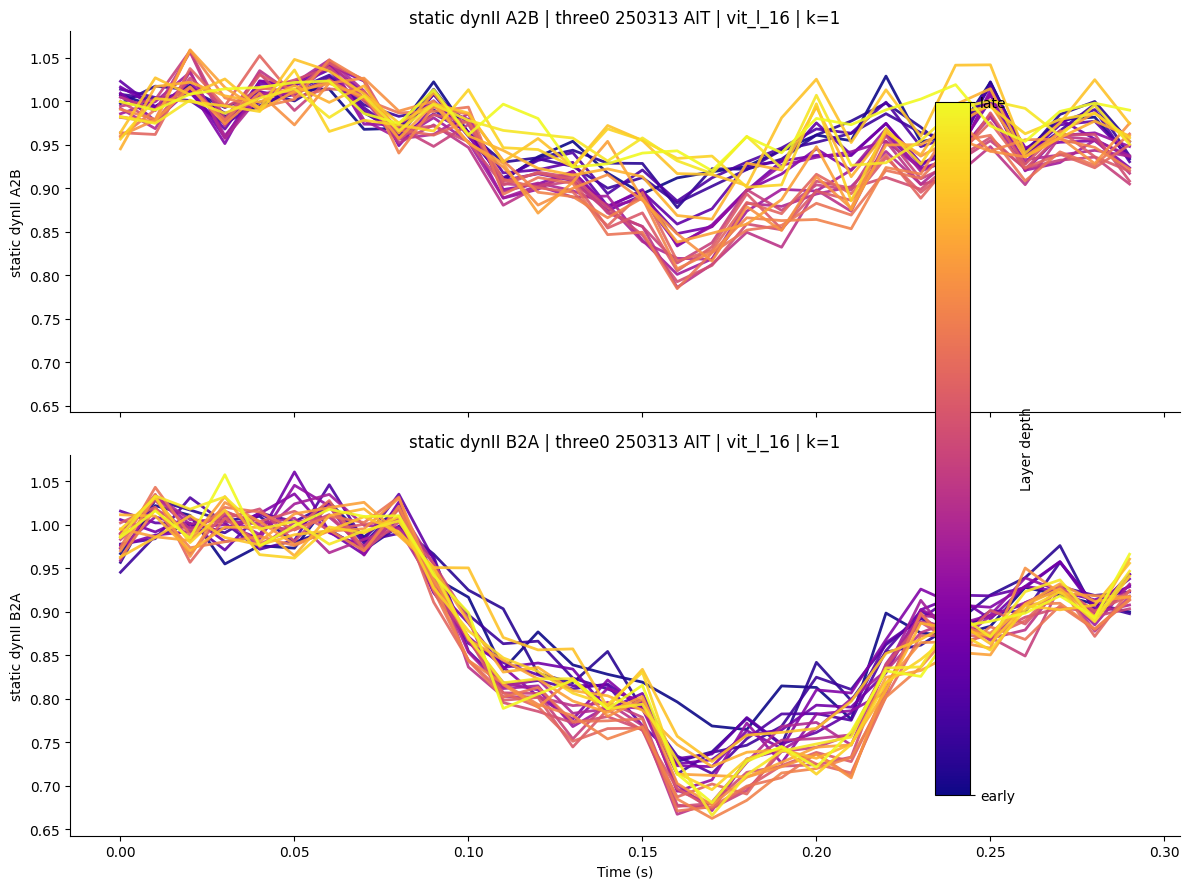

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True, sharey=True)
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for ax_i, direction in zip(ax, ["A2B", "B2A"]):
    for i, layer_name in enumerate(layers):
        if layer_name not in curves[direction]:
            continue
        dynii = curves[direction][layer_name]
        t = np.arange(len(dynii)) / cfg.new_fs
        ax_i.plot(
            t,
            dynii,
            color=cmap(norm(i)),
            linewidth=cfg.line_width,
            alpha=cfg.alpha,
            label=layer_name,
        )

    ax_i.set_ylabel(f"static dynII {direction}")
    ax_i.set_title(f"static dynII {direction} | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name} | k={cfg.k}")
    ax_i.spines[["top", "right"]].set_visible(False)
    if len(curves[direction]) <= 12:
        ax_i.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

ax[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_42795/1239038023.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


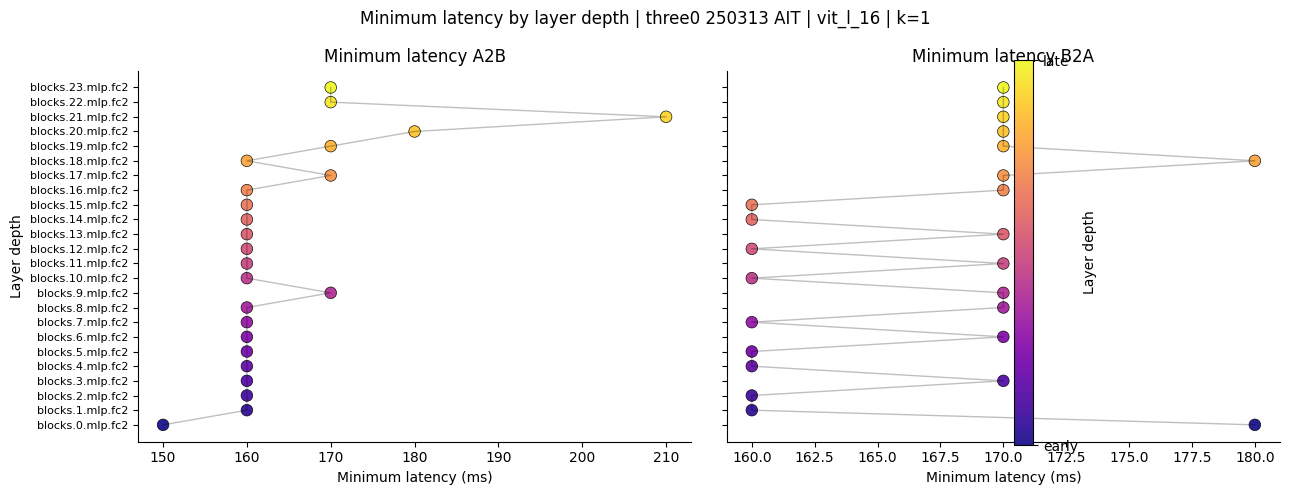

In [13]:
extremum_latencies_ms = {"A2B": [], "B2A": []}
layer_depths = {"A2B": [], "B2A": []}
layer_labels = {"A2B": [], "B2A": []}

for direction in curves:
    for layer_idx, layer_name in enumerate(layers):
        if layer_name not in curves[direction]:
            continue
        dynii = curves[direction][layer_name]
        extremum_idx = int(np.nanargmin(dynii))
        extremum_latencies_ms[direction].append(extremum_idx / cfg.new_fs * 1000)
        layer_depths[direction].append(layer_idx)
        layer_labels[direction].append(layer_name)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for ax_i, direction in zip(ax, ["A2B", "B2A"]):
    sc = ax_i.scatter(
        extremum_latencies_ms[direction],
        layer_depths[direction],
        c=layer_depths[direction],
        cmap=cmap,
        norm=norm,
        s=70,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
    )
    ax_i.plot(extremum_latencies_ms[direction], layer_depths[direction], color="black", linewidth=1, alpha=0.25)
    ax_i.set_xlabel("Minimum latency (ms)")
    ax_i.set_title(f"Minimum latency {direction}")
    ax_i.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Layer depth")
ax[0].set_yticks(layer_depths["A2B"])
ax[0].set_yticklabels(layer_labels["A2B"], fontsize=8)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

fig.suptitle(f"Minimum latency by layer depth | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name} | k={cfg.k}")
plt.tight_layout()
plt.show()


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_42795/1785403223.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


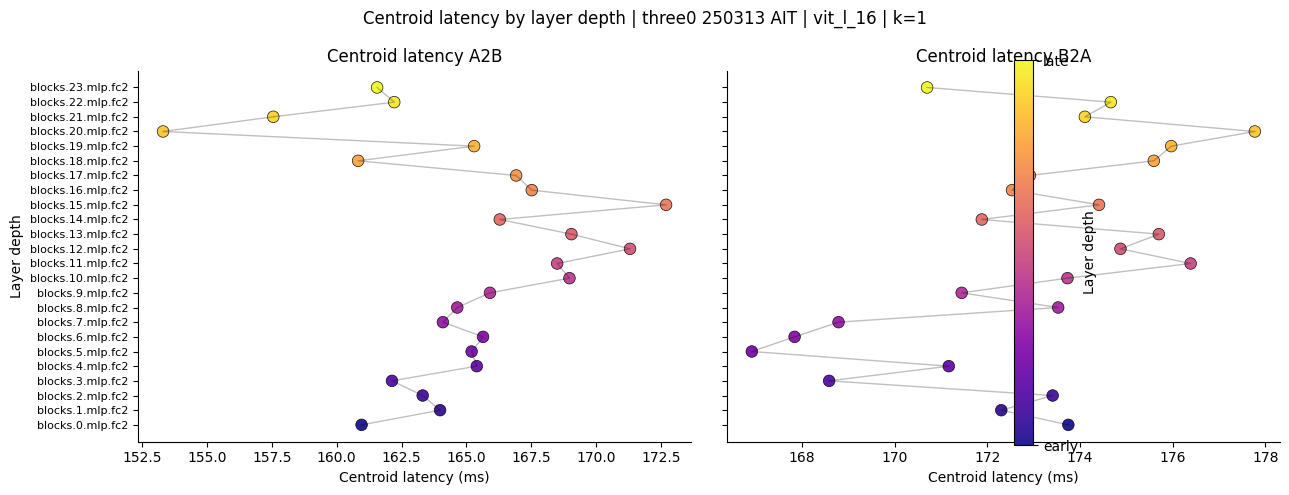

In [14]:
def get_static_dynii_centroid(curve, fs, min_depth_percent=None):
    arr = np.asarray(curve, dtype=float)
    if arr.ndim != 1:
        raise ValueError("curve must be 1D.")

    finite = np.isfinite(arr)
    if not finite.any():
        return np.nan

    weights = np.nanmax(arr) - arr
    weights = np.where(finite & (weights > 0), weights, 0.0)
    if min_depth_percent is not None:
        if not (0 <= min_depth_percent <= 1):
            raise ValueError("min_depth_percent must be in [0, 1].")
        depth = weights.max()
        weights = np.where(weights >= depth * min_depth_percent, weights, 0.0)

    denom = weights.sum()
    if denom == 0:
        return np.nan

    t = np.arange(arr.size, dtype=float) / fs
    return (weights * t).sum() / denom


centroid_latencies_ms = {"A2B": [], "B2A": []}
centroid_layer_depths = {"A2B": [], "B2A": []}
centroid_layer_labels = {"A2B": [], "B2A": []}

for direction in curves:
    for layer_idx, layer_name in enumerate(layers):
        if layer_name not in curves[direction]:
            continue
        centroid_s = get_static_dynii_centroid(curves[direction][layer_name], fs=cfg.new_fs)
        centroid_latencies_ms[direction].append(centroid_s * 1000)
        centroid_layer_depths[direction].append(layer_idx)
        centroid_layer_labels[direction].append(layer_name)

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = mpl.colormaps[cfg.cmap_name]
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for ax_i, direction in zip(ax, ["A2B", "B2A"]):
    sc = ax_i.scatter(
        centroid_latencies_ms[direction],
        centroid_layer_depths[direction],
        c=centroid_layer_depths[direction],
        cmap=cmap,
        norm=norm,
        s=70,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
    )
    ax_i.plot(centroid_latencies_ms[direction], centroid_layer_depths[direction], color="black", linewidth=1, alpha=0.25)
    ax_i.set_xlabel("Centroid latency (ms)")
    ax_i.set_title(f"Centroid latency {direction}")
    ax_i.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Layer depth")
ax[0].set_yticks(centroid_layer_depths["A2B"])
ax[0].set_yticklabels(centroid_layer_labels["A2B"], fontsize=8)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Layer depth")
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"])

fig.suptitle(f"Centroid latency by layer depth | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name} | k={cfg.k}")
plt.tight_layout()
plt.show()
